# PHASE 5 - Random Forest

This notebook trains a CPU-friendly Random Forest for hourly bike-demand prediction. The chronological train, validation, and test files from PHASE 3 are used without shuffling.

Hyperparameters are selected using validation RMSE only. The test set is evaluated once with the selected configuration.

In [ ]:
# Nhập các thư viện cần thiết
from pathlib import Path  # Làm việc với đường dẫn file
from time import perf_counter  # Đo thời gian thực thi
import pickle  # Lưu và tải các object Python

import matplotlib.pyplot as plt  # Vẽ đồ thị
import pandas as pd  # Xử lý dữ liệu
from sklearn.ensemble import RandomForestRegressor  # Model Random Forest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Các hàm tính metrics

# Hàm tìm thư mục gốc của project
def find_project_root():
    # Kiểm tra từng vị trí xem có file train.csv không
    for candidate in [Path("."), Path("..")]:
        if (candidate / "data/processed/train.csv").exists():
            return candidate
    # Nếu không tìm thấy, báo lỗi
    raise FileNotFoundError("Run PHASE 3 first to create data/processed/train.csv.")

# Tìm và lưu đường dẫn thư mục gốc
project_root = find_project_root()

# Định nghĩa các đường dẫn thư mục cần dùng
processed_dir = project_root / "data/processed"  # Thư mục dữ liệu đã xử lý
metrics_dir = project_root / "results/metrics"  # Thư mục lưu metrics
figures_dir = project_root / "results/figures"  # Thư mục lưu hình
models_dir = project_root / "models"  # Thư mục lưu mô hình

# Tạo các thư mục nếu chưa tồn tại
for directory in [metrics_dir, figures_dir, models_dir]:
    directory.mkdir(parents=True, exist_ok=True)

In [ ]:
# Hàm tải dữ liệu từ file CSV
def load_split(name):
    return pd.read_csv(processed_dir / f"{name}.csv", parse_dates=["timestamp", "dteday"])

# Tải 3 tập dữ liệu từ PHASE 3
train_df = load_split("train")  # Dữ liệu huấn luyện
validation_df = load_split("validation")  # Dữ liệu xác thực
test_df = load_split("test")  # Dữ liệu kiểm tra

# === CHUẨN BỊ DỮ LIỆU ===
target_column = "cnt"  # Cột mục tiêu: số lượng xe đạp được thuê

# Các cột cần loại bỏ
excluded_columns = {target_column, "instant", "dteday", "timestamp", "casual", "registered"}

# Lấy tất cả cột features (trừ các cột loại bỏ)
feature_columns = [column for column in train_df.columns if column not in excluded_columns]

# Chia dữ liệu thành X (features) và y (target)
X_train, y_train = train_df[feature_columns], train_df[target_column]
X_validation, y_validation = validation_df[feature_columns], validation_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]

# Kiểm tra dữ liệu theo thứ tự thời gian (tránh data leakage)
assert train_df["timestamp"].max() < validation_df["timestamp"].min()
assert validation_df["timestamp"].max() < test_df["timestamp"].min()

# In thông tin về dữ liệu
print(f"Project root: {project_root.resolve()}")
print(f"Features: {len(feature_columns)}")  # Số lượng features
print(f"Rows train/validation/test: {len(train_df)}/{len(validation_df)}/{len(test_df)}")  # Kích thước các tập

Project root: D:\bike-demand-prediction
Features: 27
Rows train/validation/test: 12047/2582/2582


## CPU-friendly validation search

The search is intentionally small. Every candidate is trained only on the training split, and validation RMSE selects the final model.

In [ ]:
# === TÌM KIẾM SIÊU THAM SỐ TỐI ƯU ===
# Danh sách các tổ hợp siêu tham số để thử
# n_estimators: số lượng cây trong rừng
# max_depth: độ sâu tối đa của mỗi cây (None = không giới hạn)
# min_samples_leaf: số mẫu tối thiểu cần có trong lá
candidates = [
    {"n_estimators": 150, "max_depth": 18, "min_samples_leaf": 1},  # Tổ hợp 1
    {"n_estimators": 200, "max_depth": 24, "min_samples_leaf": 1},  # Tổ hợp 2
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 2},  # Tổ hợp 3 (cây sâu)
]

# Hàm tính các metrics (chỉ số đánh giá)
def calculate_metrics(y_true, predictions):
    return {
        "MAE": mean_absolute_error(y_true, predictions),  # Sai số tuyệt đối trung bình
        "RMSE": mean_squared_error(y_true, predictions) ** 0.5,  # Căn bậc hai sai số bình phương trung bình
        "R2": r2_score(y_true, predictions),  # Tỷ lệ phương sai được giải thích
    }

# Danh sách lưu kết quả của từng tổ hợp siêu tham số
search_results = []

# Vòng lặp: thử từng tổ hợp siêu tham số
for parameters in candidates:
    # Tạo model Random Forest với các siêu tham số hiện tại
    # random_state=42: đặt seed để kết quả có thể tái lập
    # n_jobs=-1: sử dụng tất cả CPU cores để huấn luyện nhanh hơn
    candidate_model = RandomForestRegressor(
        **parameters, random_state=42, n_jobs=-1
    )
    
    # Bắt đầu đo thời gian
    start_time = perf_counter()
    
    # Huấn luyện model trên tập train
    candidate_model.fit(X_train, y_train)
    
    # Kết thúc đo thời gian
    elapsed = perf_counter() - start_time
    
    # Dự đoán trên tập validation
    validation_predictions = candidate_model.predict(X_validation)
    
    # Lưu kết quả: siêu tham số + metrics + thời gian
    result = {**parameters, **calculate_metrics(y_validation, validation_predictions), "training_time": elapsed}
    search_results.append(result)

# Chuyển kết quả thành DataFrame và sắp xếp theo RMSE (từ nhỏ nhất)
search_results_df = pd.DataFrame(search_results).sort_values("RMSE").reset_index(drop=True)

# Hiển thị kết quả
display(search_results_df.round(4))

# Lấy siêu tham số tốt nhất (hàng đầu tiên trong DataFrame đã sắp xếp)
best_parameters = search_results_df.iloc[0][["n_estimators", "max_depth", "min_samples_leaf"]].to_dict()

# Chuyển đổi kiểu dữ liệu từ float sang int (vì số cây và mẫu phải là số nguyên)
best_parameters["n_estimators"] = int(best_parameters["n_estimators"])
best_parameters["min_samples_leaf"] = int(best_parameters["min_samples_leaf"])

# Nếu max_depth là NaN (None), giữ nguyên là None, nếu không thì chuyển sang int
if pd.isna(best_parameters["max_depth"]):
    best_parameters["max_depth"] = None
else:
    best_parameters["max_depth"] = int(best_parameters["max_depth"])

# In ra siêu tham số được chọn
print("Selected parameters:", best_parameters)

,n_estimators,max_depth,min_samples_leaf,MAE,RMSE,R2,training_time
0,150,18.0,1,39.5649,62.3460,0.9228,1.5950
1,200,NaN,2,39.5308,62.6301,0.9220,2.9007
2,200,24.0,1,39.8388,62.8740,0.9214,2.1536


Selected parameters: {'n_estimators': 150, 'max_depth': 18, 'min_samples_leaf': 1}


In [ ]:
# === HỌC HUẤN LUYỆN MỤC TIÊU ===
# Tạo model Random Forest với siêu tham số tốt nhất đã tìm được
model = RandomForestRegressor(
    **best_parameters, random_state=42, n_jobs=-1
)

# Bắt đầu đo thời gian
start_time = perf_counter()

# Huấn luyện model trên tập train
model.fit(X_train, y_train)

# Kết thúc đo thời gian
training_time = perf_counter() - start_time

# Dự đoán trên tập validation
validation_predictions = model.predict(X_validation)

# Dự đoán trên tập test
test_predictions = model.predict(X_test)

# Tạo DataFrame lưu metrics cho cả validation và test
metrics = pd.DataFrame([
    {"model": "Random Forest", "split": "validation", **calculate_metrics(y_validation, validation_predictions), "Training Time": training_time},
    {"model": "Random Forest", "split": "test", **calculate_metrics(y_test, test_predictions), "Training Time": training_time},
])

# Hiển thị metrics
display(metrics.round(4))

# Lưu metrics vào file CSV
metrics.to_csv(metrics_dir / "random_forest_metrics.csv", index=False)

# Lưu kết quả tìm kiếm siêu tham số vào file CSV
search_results_df.to_csv(metrics_dir / "random_forest_validation_search.csv", index=False)

,model,split,MAE,RMSE,R2,Training Time
0,Random Forest,validation,39.5649,62.3460,0.9228,1.974
1,Random Forest,test,37.3624,62.7308,0.9140,1.974


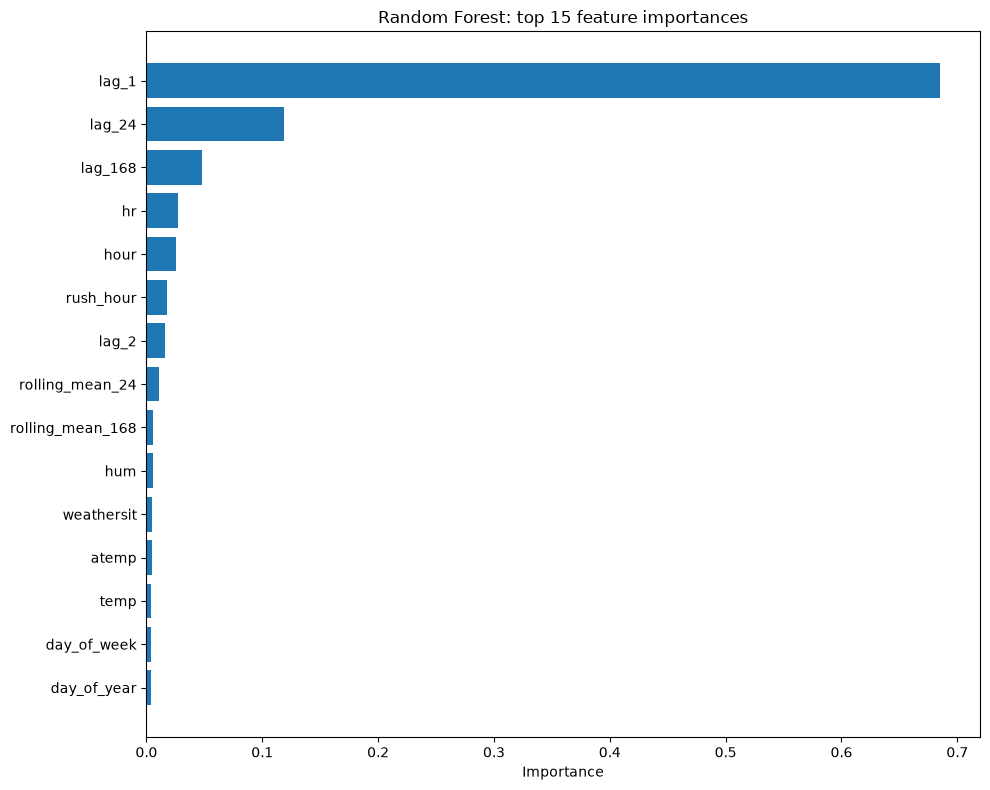

,feature,importance
21,lag_1,0.685292
23,lag_24,0.118474
24,lag_168,0.048410
3,hr,0.027174
12,hour,0.025561
20,rush_hour,0.018058
22,lag_2,0.015864
25,rolling_mean_24,0.011045
26,rolling_mean_168,0.005661
10,hum,0.005288


In [ ]:
# === TÍ TRỌNG FEATURES ===
# Tạo DataFrame chứa tên feature và độ quan trọng của nó
# model.feature_importances_: mảng chứa độ quan trọng của mỗi feature
importance = pd.DataFrame({
    "feature": feature_columns,  # Tên các features
    "importance": model.feature_importances_,  # Độ quan trọng (0-1)
}).sort_values("importance", ascending=False)  # Sắp xếp từ cao đến thấp

# Lưu bảng độ quan trọng vào file CSV
importance.to_csv(metrics_dir / "random_forest_feature_importance.csv", index=False)

# === VẼ BIỂU ĐỒ ===
# Tạo biểu đồ với kích thước 10x8 inch
plt.figure(figsize=(10, 8))

# Lấy top 15 features có độ quan trọng cao nhất và sắp xếp tăng dần (để vẽ dễ nhìn)
top_importance = importance.head(15).sort_values("importance")

# Vẽ biểu đồ cột ngang (barh)
plt.barh(top_importance["feature"], top_importance["importance"])

# Đặt tiêu đề và nhãn trục
plt.title("Random Forest: top 15 feature importances")
plt.xlabel("Importance")

# Điều chỉnh layout
plt.tight_layout()

# Lưu biểu đồ thành file ảnh
plt.savefig(figures_dir / "random_forest_feature_importance.png", dpi=150)

# Hiển thị biểu đồ
plt.show()

# Hiển thị bảng top 15 features
display(importance.head(15))

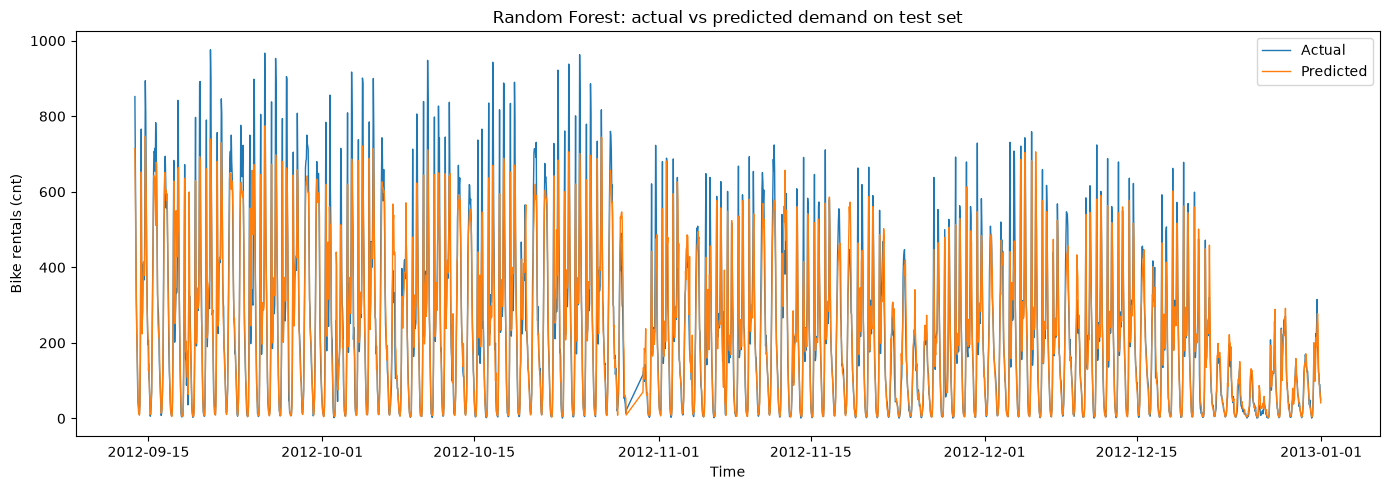

Saved model to: ..\models\random_forest.pkl


In [ ]:
# === VẼ SO SÁNH DỰ ĐOÁN VỚI GIỐNG TỰC TẾ ===
# Tạo DataFrame so sánh giá trị thực tế và dự đoán trên tập test
comparison = pd.DataFrame({
    "timestamp": test_df["timestamp"],  # Thời gian
    "actual": y_test.to_numpy(),  # Giá trị thực tế (số xe đạp được thuê)
    "predicted": test_predictions,  # Giá trị dự đoán của model
})

# Tạo biểu đồ với kích thước 14x5 inch
plt.figure(figsize=(14, 5))

# Vẽ đường thực tế
plt.plot(comparison["timestamp"], comparison["actual"], label="Actual", linewidth=1)

# Vẽ đường dự đoán
plt.plot(comparison["timestamp"], comparison["predicted"], label="Predicted", linewidth=1)

# Đặt tiêu đề và nhãn trục
plt.title("Random Forest: actual vs predicted demand on test set")
plt.xlabel("Time")
plt.ylabel("Bike rentals (cnt)")

# Thêm chú thích
plt.legend()

# Điều chỉnh layout
plt.tight_layout()

# Lưu biểu đồ
plt.savefig(figures_dir / "random_forest_actual_vs_predicted.png", dpi=150)

# Hiển thị biểu đồ
plt.show()

# === LƯU MỘ HÌNH ===
# Định nghĩa đường dẫn lưu model
model_path = models_dir / "random_forest.pkl"

# Mở file ở chế độ ghi nhị phân
with model_path.open("wb") as model_file:
    # Lưu model và danh sách features
    pickle.dump({"model": model, "feature_columns": feature_columns}, model_file)

# In thông báo đã lưu thành công
print(f"Saved model to: {model_path}")

## Phase 5 conclusion

The selected Random Forest is evaluated on untouched test data and its metrics can be compared with PHASE 4.